In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd 
import os
from src.nn.nn_dataset import DataSampler
from src.functions import *
from src.nn.nn_actions import NeuralNetworkActions
from src.ode.sm_models_d import SynchronousMachineModels
from omegaconf import OmegaConf
import wandb

%load_ext autoreload
%autoreload 2


In [6]:
cfg = OmegaConf.load("src/conf/setup_dataset_nn.yaml")
cfg.seed = 1
if cfg.nn.optimizer == "LBFGS":
    cfg.nn.num_epochs = int(cfg.nn.num_epochs /10)
    cfg.nn.weighting.update_weights_freq = int(cfg.nn.weighting.update_weights_freq)
modelling_full = SynchronousMachineModels(cfg)
network2 = NeuralNetworkActions(cfg, modelling_full)
#network.load_model("data\model_10000_5000_300_53_1_0_0.pth")


num_of_skip_data_points = 23
num_of_skip_col_points = 41
num_of_skip_val_points = 4

run = None
network2.pinn_train2(num_of_skip_data_points, num_of_skip_col_points, num_of_skip_val_points,run)



SM data
Loading data from:  ./data/SM/dataset_v6.pkl
Number of training samples:  400000 Number of validation samples:  50000 Number of testing samples:  50000
Number of different initial conditions for collocation points:  5000
['theta', 'omega', 'E_d_dash', 'E_q_dash'] Variables
[[-2, 2], [-2, 2], [0], [0.9, 1.1]] Set of values for init conditions
[10, 100, 1, 5] Iterations per value
########HERE##### DynamicNN
Number of labeled training data:  17392  number of collocation points:  121952  number of collocation points ic:  5000  number of validation data:  12500
Weights initialized as:  [0, 0, 10, 10000]  are updated with scheme:  Static every  50  epochs
getting in training
Validation loss decreased (inf --> 0.324682).  Saving model ...
Updated Weights [0.0, 0.0, 10.0, 10000.0]
Epoch [50/1500], Loss: 26.5148, Loss_data: 0.1307, Loss_dt: 2.2807, Loss_pinn: 1.9248 , Loss_pinn_ic : 0.0007 0.1569911241531372
Updated Weights [0.0, 0.0, 10.0, 10000.0]
Epoch [100/1500], Loss: 9.3414, Loss_

KeyboardInterrupt: 

In [ ]:
Gradient
Epoch [200/1500], Loss: 3.9727, Loss_data: 0.0341, Loss_dt: 0.6516, Loss_pinn: 0.4960 , Loss_pinn_ic : 0.0001 0.041247207671403885
Ntk
Epoch [200/1500], Loss: 6.2800, Loss_data: 0.0536, Loss_dt: 0.7276, Loss_pinn: 0.6854 , Loss_pinn_ic : 0.0003 0.06317942589521408
static
Epoch [200/1500], Loss: 4.8764, Loss_data: 0.0223, Loss_dt: 0.5546, Loss_pinn: 0.4207 , Loss_pinn_ic : 0.0001 0.02685326524078846


In [ ]:
x_train, y_train, x_train_col, x_train_col0, y_train_col0, x_val, y_val = network2.define_train_val_data2(0, 1, num_of_skip_data_points, num_of_skip_col_points, num_of_skip_val_points)


tensor([[0.0000, 1.6896, 0.1708, 0.0000, 1.0316],
        [0.0040, 1.6896, 0.1708, 0.0000, 1.0316],
        [0.0080, 1.6896, 0.1708, 0.0000, 1.0316],
        ...,
        [0.9882, 1.1751, 0.0987, 0.0000, 0.9004],
        [0.9922, 1.1751, 0.0987, 0.0000, 0.9004],
        [0.9962, 1.1751, 0.0987, 0.0000, 0.9004]], device='cuda:0',
       grad_fn=<ToCopyBackward0>)

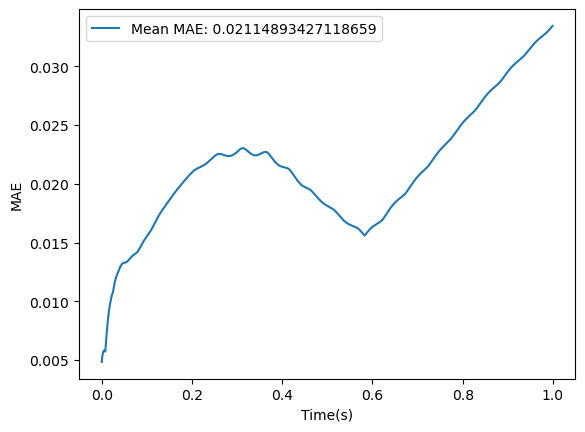

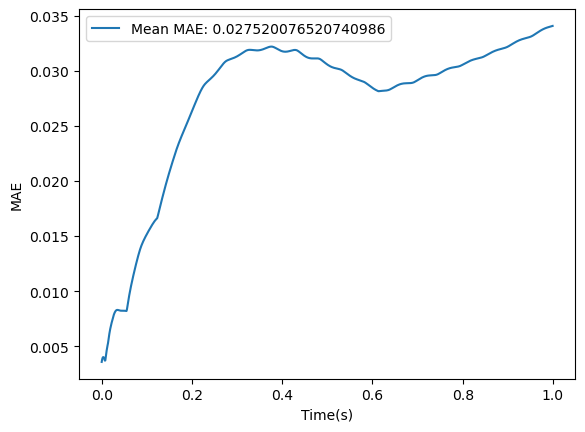

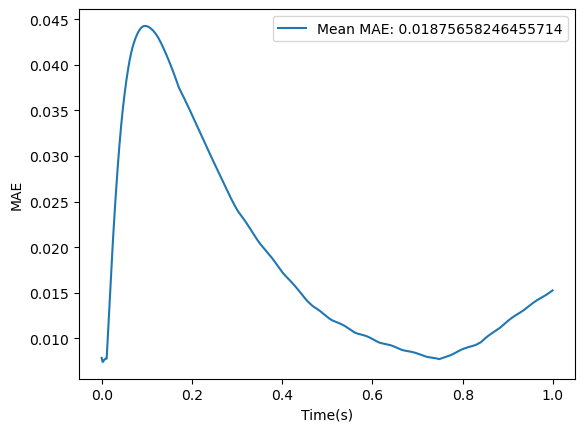

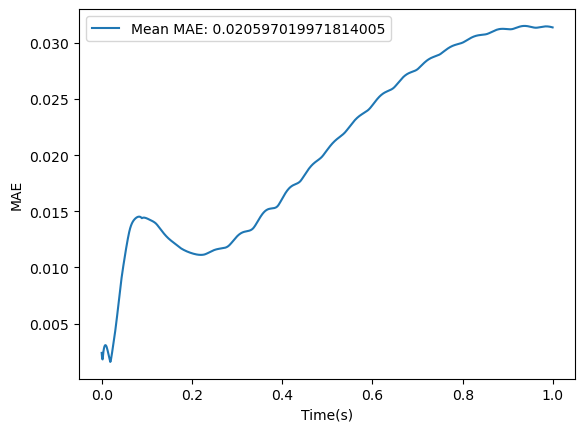

In [7]:
network2.final_name ="ncs"
out1, oute2 =network2.loss_over_time(x_test, y_test, y_pred)
unique_values = torch.unique(x_test[:,0]) 
for i in range(out1.shape[1]):
            
    plt.figure()

    mean_mae = np.mean(out1[:,i])

    plt.plot(unique_values.detach().cpu().numpy(), out1[:,i], label=f"Mean MAE: {mean_mae}")
    plt.xlabel("Time(s)")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()


KAN
None
tensor(0.5216, device='cuda:0', grad_fn=<MseLossBackward0>)


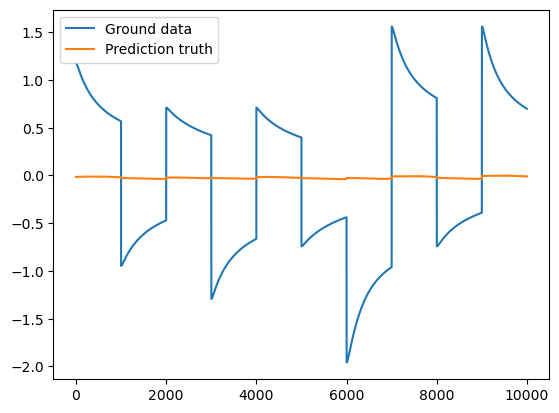

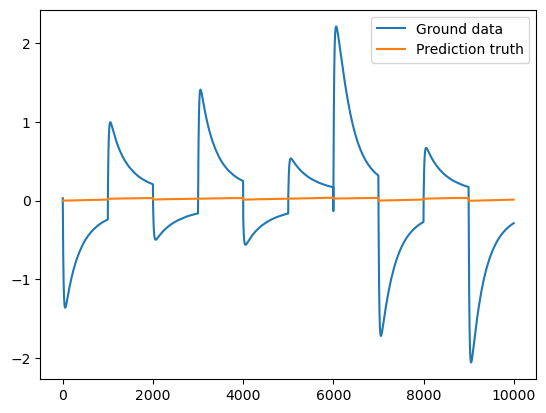

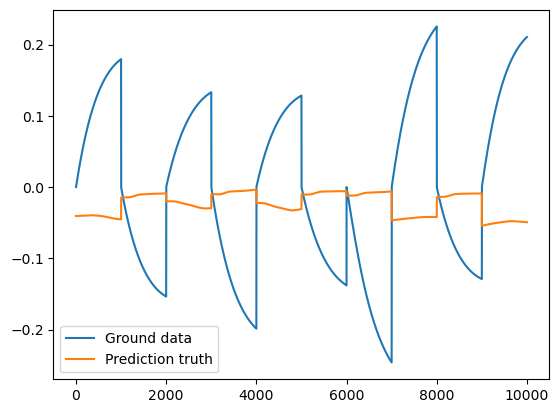

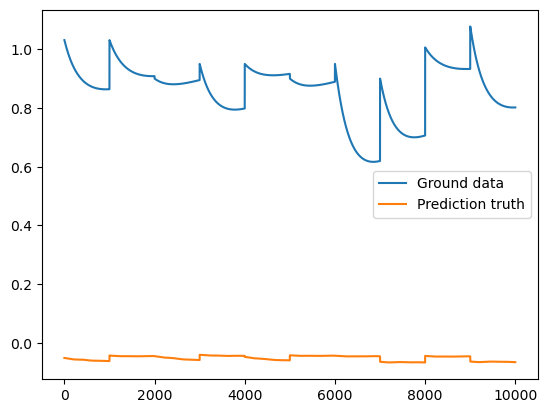

In [3]:
sample_per_traj = 1000
starting_traj = 1
total_traj = 100
x_test = network2.data_loader.x_test[starting_traj*sample_per_traj:(starting_traj+total_traj)*sample_per_traj].clone().detach().to(network2.device).requires_grad_(True)
y_test = network2.data_loader.y_test[starting_traj*sample_per_traj:(starting_traj+total_traj)*sample_per_traj].clone().detach().to(network2.device)
network2.model.eval()
x_test = network2.transform_input(x_test)

y_test_old = y_test.clone().detach()
##y_test = network.data_loader.adjust_target(x_test, y_test)
y_pred = network2.forward_pass(x_test)
#y_pred0 = network.forward_pass(x_test)
y_test_old = network2.transform_output(y_test_old)
print(network2.cfg.nn.type)
print(network2.cfg.dataset.transform_input)
loss = network2.criterion(y_pred, y_test_old)
print(loss)
limit = sample_per_traj*10

for var in range(y_test.shape[1]):
    plt.plot(y_test_old[:limit,var].cpu().detach().numpy(), label='Ground data')
    plt.plot(y_pred[:limit,var].cpu().detach().numpy(), label='Prediction truth')
    #plt.plot(y_pred0[:limit,var].cpu().detach().numpy(), label='Prediction truth more data')
    #plt.plot(y_pred_old1[:limit,var].cpu().detach().numpy(), label='Prediction truth only data')
    plt.legend()
    plt.show()



In [4]:
# measure time
import time
start = time.time()
for i in range(100):
    y= network2.forward_pass(x_test)
end = time.time()
print(end - start)
print(x_test.shape)
#print average of 

#network2.test_model( starting_traj=0, total_traj=50)

6.1110148429870605
torch.Size([49000, 5])
